# 03 — West Java Rice Productivity by Regency/City (DS03)
**TaniAdapt Project — Regional Rice Outcome Target**
**Fase:** Phase 3 (Discovery & Acquisition) + Phase 4 (Dataset Quality Audit)

- **Sumber Resmi:** Dinas Tanaman Pangan dan Hortikultura (Distanhor) Jawa Barat / Galura Data Jabar
- **Cakupan Wilayah:** 27 Kabupaten/Kota di Jawa Barat (2015–2020)
- **Varian Komoditas:** Padi Total, Padi Sawah (Wetland), dan Padi Ladang (Dryland)
- **Catatan Granularitas Kritis:** Data luaran bersifat **tahunan murni** (tidak ada pemisahan per musim tanam MH/MK di dataset resmi). Pasangan cuaca saat ini berjumlah **42 baris** (7 kabupaten AgERA5 x 6 tahun).


In [1]:
from pathlib import Path
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

CWD = Path.cwd().resolve()
PROJECT_ROOT = CWD.parent if CWD.name.lower() == "notebook" else CWD
RAW_DIR = PROJECT_ROOT / "data" / "raw" / "DS03_west_java_rice_productivity"
FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project Root:", PROJECT_ROOT)
print("Raw Data Dir:", RAW_DIR)


Project Root: C:\CODING\research_taniAdapt
Raw Data Dir: C:\CODING\research_taniAdapt\data\raw\DS03_west_java_rice_productivity


## Phase 3 & 4 — Audit Integritas & Kelengkapan Matriks Panel (27 Wilayah x 6 Tahun)
Memeriksa file Padi Total, Padi Sawah, dan Padi Ladang yang diperoleh dari API resmi Galura.


In [2]:
df_total = pd.read_csv(RAW_DIR / "produktivitas_padi_jabar.csv")
df_sawah = pd.read_csv(RAW_DIR / "produktivitas_padi_sawah_jabar.csv")
df_ladang = pd.read_csv(RAW_DIR / "produktivitas_padi_ladang_jabar.csv")

print("Dimensi & Missing Values:")
print(f"  Padi Total : {df_total.shape} | Missing: {df_total['produktivitas_padi2'].isnull().sum()}")
print(f"  Padi Sawah : {df_sawah.shape} | Missing: {df_sawah['produktivitas_padi'].isnull().sum()}")
print(f"  Padi Ladang: {df_ladang.shape} | Missing: {df_ladang['produktivitas_padi'].isnull().sum()}")

# Validasi Kelengkapan Matriks Penuh
expected_rows = 27 * 6
is_complete = (len(df_total) == expected_rows)
print("\n" + "="*50)
print(f"KELENGKAPAN MATRIKS (27 kab/kota x 6 tahun = {expected_rows} baris): {is_complete}")
print("STATUS INTEGRITAS     :", "[PASSED]" if is_complete else "[FAILED]")
print("Satuan Resmi          :", df_total['satuan'].iloc[0])

# Cek sampel efektif terhadap 7 titik AgERA5 saat ini
locs_agera5 = ["BANDUNG", "KARAWANG", "TASIKMALAYA", "SUKABUMI", "CIREBON", "PURWAKARTA", "BEKASI"]
kab_matched = [f"KABUPATEN {loc}" for loc in locs_agera5]
n_eff = len(df_total[df_total['nama_kabupaten_kota'].isin(kab_matched)])
print(f"Sampel Efektif (Matching 7 Titik AgERA5 Saat Ini): N_eff = {n_eff} baris (7 kab x 6 tahun)")
print("="*50)


Dimensi & Missing Values:
  Padi Total : (162, 8) | Missing: 0
  Padi Sawah : (162, 8) | Missing: 0
  Padi Ladang: (162, 8) | Missing: 0

KELENGKAPAN MATRIKS (27 kab/kota x 6 tahun = 162 baris): True
STATUS INTEGRITAS     : [PASSED]
Satuan Resmi          : KUINTAL PER HEKTAR


Sampel Efektif (Matching 7 Titik AgERA5 Saat Ini): N_eff = 42 baris (7 kab x 6 tahun)


## Statistik Produktivitas Tahunan (Kuintal/Hektar)


In [3]:
display(df_total.groupby('tahun')['produktivitas_padi2'].describe())


,count,mean,std,min,25%,50%,75%,max
tahun,,,,,,,,
2015,27.0,60.193704,4.259380,51.97,57.575,59.76,62.800,68.95
2016,27.0,59.576296,3.250998,53.40,56.860,60.29,61.795,65.31
2017,27.0,57.466296,5.548348,39.63,55.010,58.04,60.395,66.45
2018,27.0,55.390741,3.744822,48.91,53.030,55.45,57.315,63.93
2019,27.0,68.545185,4.889340,58.89,65.840,68.09,72.345,77.01
2020,27.0,54.221481,3.969630,45.94,52.595,54.34,57.165,60.31


## Visualisasi Diagnostik Multi-Panel (Rata-rata Padi Total & Gap Sawah vs Ladang)
Perbandingan produktivitas tahunan dan disparitas antara padi sawah (irigasi) vs padi ladang (tadah hujan).


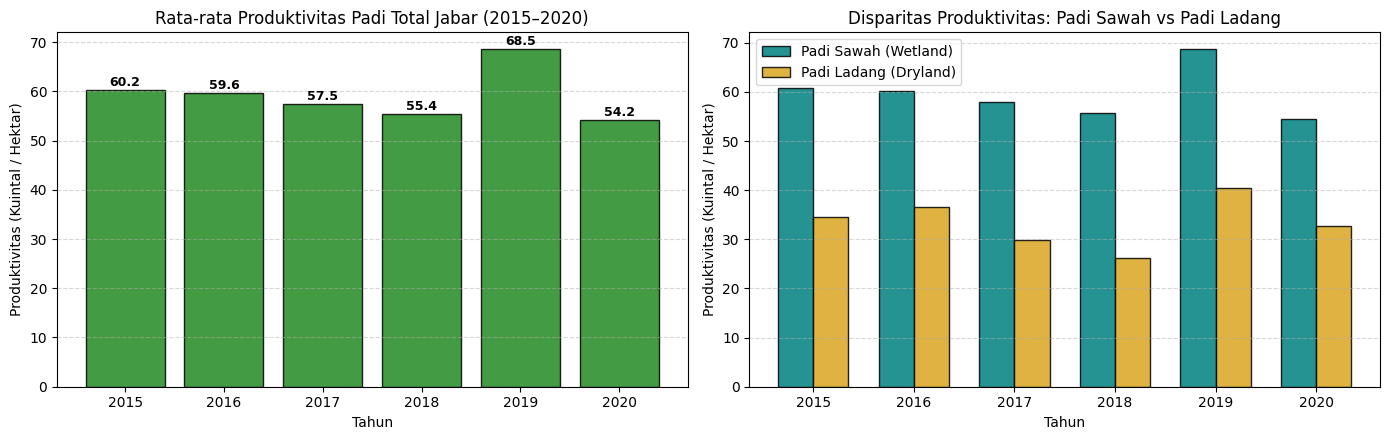

Gambar PNG berhasil disimpan ke: C:\CODING\research_taniAdapt\reports\figures\ds03_rice_coverage.png


In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Panel 1: Rata-rata Padi Total
mean_total = df_total.groupby('tahun')['produktivitas_padi2'].mean()
ax1.bar(mean_total.index.astype(str), mean_total.values, color='forestgreen', edgecolor='black', alpha=0.85)
ax1.set_title("Rata-rata Produktivitas Padi Total Jabar (2015–2020)")
ax1.set_xlabel("Tahun")
ax1.set_ylabel("Produktivitas (Kuintal / Hektar)")
ax1.grid(axis='y', linestyle='--', alpha=0.5)
for i, v in enumerate(mean_total.values):
    ax1.text(i, v + 0.8, f"{v:.1f}", ha='center', fontsize=9, fontweight='bold')

# Panel 2: Komparasi Padi Sawah vs Padi Ladang
mean_sawah = df_sawah.groupby('tahun')['produktivitas_padi'].mean()
mean_ladang = df_ladang.groupby('tahun')['produktivitas_padi'].mean()

years = np.arange(len(mean_sawah))
width = 0.35
ax2.bar(years - width/2, mean_sawah.values, width, label='Padi Sawah (Wetland)', color='teal', edgecolor='black', alpha=0.85)
ax2.bar(years + width/2, mean_ladang.values, width, label='Padi Ladang (Dryland)', color='goldenrod', edgecolor='black', alpha=0.85)
ax2.set_title("Disparitas Produktivitas: Padi Sawah vs Padi Ladang")
ax2.set_xlabel("Tahun")
ax2.set_ylabel("Produktivitas (Kuintal / Hektar)")
ax2.set_xticks(years)
ax2.set_xticklabels(mean_sawah.index.astype(str))
ax2.legend()
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
png_out = FIGURES_DIR / "ds03_rice_coverage.png"
plt.savefig(png_out, dpi=150)
plt.show()
print(f"Gambar PNG berhasil disimpan ke: {png_out}")


## Executive Audit Scorecard


In [5]:
scorecard = pd.DataFrame([
    {"Dimensi Audit": "Dataset Identifier", "Hasil & Evaluasi": "DS03 — West Java Rice Productivity by Regency/City"},
    {"Dimensi Audit": "Penerbit & Sumber", "Hasil & Evaluasi": "Distanhor Jabar / Galura Open Data Jabar"},
    {"Dimensi Audit": "Cakupan Wilayah", "Hasil & Evaluasi": "27 Kabupaten/Kota Se-Jawa Barat"},
    {"Dimensi Audit": "Rentang Periode", "Hasil & Evaluasi": "2015 s.d. 2020 (6 Tahun Observasi Penuh)"},
    {"Dimensi Audit": "Varian Komoditas", "Hasil & Evaluasi": "Padi Total, Padi Sawah (Wetland), Padi Ladang (Dryland)"},
    {"Dimensi Audit": "Kelengkapan Matriks", "Hasil & Evaluasi": "PASSED (162 baris per varian, 0 missing value)"},
    {"Dimensi Audit": "Sampel Efektif Saat Ini", "Hasil & Evaluasi": "N_eff = 42 baris berpasangan dengan 7 titik cuaca AgERA5"},
    {"Dimensi Audit": "Satuan Resmi", "Hasil & Evaluasi": "Kuintal / Hektar (1 Kuintal = 100 kg = 0,1 ton)"},
    {"Dimensi Audit": "Peran di TaniAdapt", "Hasil & Evaluasi": "Regional Rice Outcome Target"},
    {"Dimensi Audit": "Status Disposisi", "Hasil & Evaluasi": "PASS (Target hasil panen padi lokal resmi)"},
    {"Dimensi Audit": "Batasan Kritis", "Hasil & Evaluasi": "Outcome murni tahunan; tidak ada data terpisah MH/MK di dataset resmi."}
])

display(scorecard)


,Dimensi Audit,Hasil & Evaluasi
0,Dataset Identifier,DS03 — West Java Rice Productivity by Regency/...
1,Penerbit & Sumber,Distanhor Jabar / Galura Open Data Jabar
2,Cakupan Wilayah,27 Kabupaten/Kota Se-Jawa Barat
3,Rentang Periode,2015 s.d. 2020 (6 Tahun Observasi Penuh)
4,Varian Komoditas,"Padi Total, Padi Sawah (Wetland), Padi Ladang ..."
5,Kelengkapan Matriks,"PASSED (162 baris per varian, 0 missing value)"
6,Sampel Efektif Saat Ini,N_eff = 42 baris berpasangan dengan 7 titik cu...
7,Satuan Resmi,"Kuintal / Hektar (1 Kuintal = 100 kg = 0,1 ton)"
8,Peran di TaniAdapt,Regional Rice Outcome Target
9,Status Disposisi,PASS (Target hasil panen padi lokal resmi)
